In [1]:
#1
from google.colab import files
uploaded=files.upload()

Saving german.data to german.data


In [2]:
#2
import pandas as pd

df = pd.read_csv("german.data", sep=" ", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
#3
import pandas as pd
columns = [
    "CheckingAccount", "Duration", "CreditHistory", "Purpose",
    "CreditAmount", "SavingsAccount", "EmploymentSince",
    "InstallmentRate", "PersonalStatusSex", "OtherDebtors",
    "ResidenceSince", "Property", "Age",
    "OtherInstallmentPlans", "Housing",
    "ExistingCredits", "Job", "Dependents",
    "Telephone", "ForeignWorker", "Risk"
]
df = pd.read_csv("german.data", sep=" ", header=None)
df.columns = columns

df.head()

,CheckingAccount,Duration,CreditHistory,Purpose,CreditAmount,SavingsAccount,EmploymentSince,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,Dependents,Telephone,ForeignWorker,Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
#4
df["Risk"] = df["Risk"].map({1: "Low Risk", 2: "High Risk"})
df["Risk"].value_counts()

,count
Risk,
Low Risk,700
High Risk,300


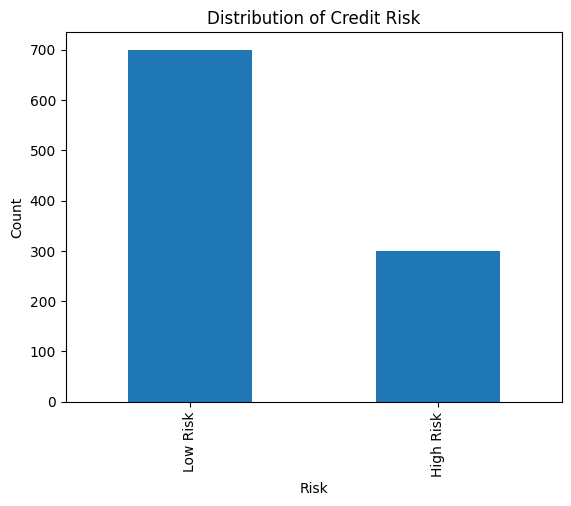

In [5]:
#5
import matplotlib.pyplot as plt

df["Risk"].value_counts().plot(kind='bar')
plt.title("Distribution of Credit Risk")
plt.ylabel("Count")
plt.show()

In [6]:
#6
# Step 1: Separate target
y = df["Risk"]

# Step 2: Features
X = df.drop("Risk", axis=1)

# Step 3: Encode only features
X_encoded = pd.get_dummies(X, drop_first=True)

# Step 4: Convert target to numeric
y_encoded = y.map({"Low Risk":0, "High Risk":1})

X_encoded.head()

,Duration,CreditAmount,InstallmentRate,ResidenceSince,Age,ExistingCredits,Dependents,CheckingAccount_A12,CheckingAccount_A13,CheckingAccount_A14,...,Property_A124,OtherInstallmentPlans_A142,OtherInstallmentPlans_A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,ForeignWorker_A202
0,6,1169,4,4,67,2,1,False,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,True,False,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,False,False,True,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,False,False,False,...,True,False,True,False,True,False,True,False,False,False


In [7]:
#7

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [8]:
#8
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()

X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [9]:
#9
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    random_state=42
)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_model

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

In [10]:

#10
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

# train model
rf_model.fit(X_train, y_train)

# make predictions
rf_pred = rf_model.predict(X_test)

In [11]:
#11
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,50),
    max_iter=700,
    random_state=42
)
mlp_model.fit(X_train, y_train)

mlp_pred = mlp_model.predict(X_test)
mlp_model

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=700, random_state=42)

In [12]:
#12
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    }

log_results = evaluate_model(log_model)
rf_results = evaluate_model(rf_model)
mlp_results = evaluate_model(mlp_model)

In [13]:
#13
results_table = pd.DataFrame([
    log_results,
    rf_results,
    mlp_results
], index=["Logistic Regression", "Random Forest", "Neural Network"])

results_table

,Accuracy,Precision,Recall,F1 Score,AUC
Logistic Regression,0.750,0.558140,0.800000,0.657534,0.803095
Random Forest,0.750,0.596154,0.516667,0.553571,0.799524
Neural Network,0.775,0.627119,0.616667,0.621849,0.812619


In [14]:
#14
print(X_encoded.columns)
X_encoded.shape

Index(['Duration', 'CreditAmount', 'InstallmentRate', 'ResidenceSince', 'Age',
       'ExistingCredits', 'Dependents', 'CheckingAccount_A12',
       'CheckingAccount_A13', 'CheckingAccount_A14', 'CreditHistory_A31',
       'CreditHistory_A32', 'CreditHistory_A33', 'CreditHistory_A34',
       'Purpose_A41', 'Purpose_A410', 'Purpose_A42', 'Purpose_A43',
       'Purpose_A44', 'Purpose_A45', 'Purpose_A46', 'Purpose_A48',
       'Purpose_A49', 'SavingsAccount_A62', 'SavingsAccount_A63',
       'SavingsAccount_A64', 'SavingsAccount_A65', 'EmploymentSince_A72',
       'EmploymentSince_A73', 'EmploymentSince_A74', 'EmploymentSince_A75',
       'PersonalStatusSex_A92', 'PersonalStatusSex_A93',
       'PersonalStatusSex_A94', 'OtherDebtors_A102', 'OtherDebtors_A103',
       'Property_A122', 'Property_A123', 'Property_A124',
       'OtherInstallmentPlans_A142', 'OtherInstallmentPlans_A143',
       'Housing_A152', 'Housing_A153', 'Job_A172', 'Job_A173', 'Job_A174',
       'Telephone_A192', 'Foreig

(1000, 48)

In [15]:
#15
import pandas as pd

coef_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "coefficient": log_model.coef_[0]
})

coef_df = coef_df.sort_values(by="coefficient", ascending=False)

print(coef_df.head(10))

            feature  coefficient
38    Property_A124     0.422324
1      CreditAmount     0.405536
2   InstallmentRate     0.381396
0          Duration     0.301863
44         Job_A173     0.236672
43         Job_A172     0.199846
45         Job_A174     0.138203
20      Purpose_A46     0.134633
37    Property_A123     0.116603
6        Dependents     0.106617


In [16]:
#16
wrong_mask = (mlp_pred != y_test)

X_test_df = X_encoded.loc[y_test.index]

X_wrong = X_test_df[wrong_mask]
y_wrong = y_test[wrong_mask]

print("Wrong predictions:", len(X_wrong))

Wrong predictions: 45


In [17]:
#17
from sklearn.tree import DecisionTreeClassifier

rule_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

rule_tree.fit(X_wrong, y_wrong)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [18]:
#18
from sklearn.tree import export_text

rules = export_text(rule_tree, feature_names=list(X_wrong.columns))
print(rules)

|--- CreditHistory_A32 <= 0.50
|   |--- Dependents <= 1.50
|   |   |--- ResidenceSince <= 1.50
|   |   |   |--- class: 0
|   |   |--- ResidenceSince >  1.50
|   |   |   |--- class: 1
|   |--- Dependents >  1.50
|   |   |--- OtherInstallmentPlans_A143 <= 0.50
|   |   |   |--- class: 0
|   |   |--- OtherInstallmentPlans_A143 >  0.50
|   |   |   |--- class: 1
|--- CreditHistory_A32 >  0.50
|   |--- Purpose_A49 <= 0.50
|   |   |--- CreditAmount <= 1694.50
|   |   |   |--- class: 1
|   |   |--- CreditAmount >  1694.50
|   |   |   |--- class: 0
|   |--- Purpose_A49 >  0.50
|   |   |--- class: 1



In [19]:
#19
def rule_engine_with_confidence(row, ml_prediction, probability):

    final_prediction = ml_prediction

    # apply symbolic correction when NN is moderately uncertain
    if 0.35 <= probability <= 0.65:

        tree_pred = rule_tree.predict(row.values.reshape(1, -1))[0]

        # only override if tree disagrees
        if tree_pred != ml_prediction:
            final_prediction = tree_pred

    return final_prediction, []

In [20]:
#20
import numpy as np

ns_predictions = []
explanations_list = []

for i in range(len(X_test)):

    # Convert row to dataframe for rule engine
    row = X_test_df.iloc[i]

    # Neural Network prediction (base model for NS)
    ml_pred = mlp_model.predict(X_test[i:i+1])[0]
    prob = mlp_model.predict_proba(X_test[i:i+1])[0][1]

    # Apply symbolic rules
    final_pred, explanations = rule_engine_with_confidence(row, ml_pred, prob)

    ns_predictions.append(final_pred)
    explanations_list.append(explanations)

# Convert to numpy array
ns_predictions = np.array(ns_predictions)

# Evaluate Neuro-Symbolic model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

ns_accuracy = accuracy_score(y_test, ns_predictions)
ns_precision = precision_score(y_test, ns_predictions)
ns_recall = recall_score(y_test, ns_predictions)
ns_f1 = f1_score(y_test, ns_predictions)

print("Neuro-Symbolic Model Performance")
print("Accuracy:", ns_accuracy)
print("Precision:", ns_precision)
print("Recall:", ns_recall)
print("F1 Score:", ns_f1)

Neuro-Symbolic Model Performance
Accuracy: 0.795
Precision: 0.6666666666666666
Recall: 0.6333333333333333
F1 Score: 0.6495726495726496


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local

In [21]:
#21
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Neural Network",
        "Neuro-Symbolic"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, mlp_pred),
        accuracy_score(y_test, ns_predictions)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, mlp_pred),
        precision_score(y_test, ns_predictions)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, mlp_pred),
        recall_score(y_test, ns_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, mlp_pred),
        f1_score(y_test, ns_predictions)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression     0.750   0.558140  0.800000  0.657534
1        Random Forest     0.750   0.596154  0.516667  0.553571
2       Neural Network     0.775   0.627119  0.616667  0.621849
3       Neuro-Symbolic     0.795   0.666667  0.633333  0.649573


In [22]:
uncertain_idx = np.where((mlp_model.predict_proba(X_test)[:,1] > 0.35) &
                         (mlp_model.predict_proba(X_test)[:,1] < 0.65))[0]

print("Uncertain predictions:", len(uncertain_idx))

Uncertain predictions: 9


In [23]:
np.sum(ns_predictions != mlp_pred)

np.int64(6)

In [24]:
improved = np.sum((mlp_pred != y_test) & (ns_predictions == y_test))
worsened = np.sum((mlp_pred == y_test) & (ns_predictions != y_test))

print("Improved:", improved)
print("Worsened:", worsened)

Improved: 5
Worsened: 1
